## Visualización inicial de los Datos

In [1]:
import pandas as pd

# Cargar el dataset
df = pd.read_csv('customer_support_tickets.csv')

# 1. Ver las columnas disponibles
print("=== COLUMNAS DEL DATASET ===")
print(df.columns.tolist())

# 2. Ver la forma del dataset (filas, columnas)
print(f"\nEl dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

# 3. Mostrar las primeras 3 filas para entender el contenido
display(df.head(3))

=== COLUMNAS DEL DATASET ===
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']

El dataset tiene 8469 filas y 17 columnas.


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


## 1. Selección de Características y Concatenación de Texto

Para el entrenamiento del modelo Naïve Bayes, no necesitamos los datos demográficos del cliente. Nos enfocaremos en la variable objetivo (`Ticket Type`) y en el texto del ticket. 
Se concatenarán las columnas `Ticket Subject` y `Ticket Description` para maximizar la información léxica disponible para la bolsa de palabras (Bag of Words).

In [2]:
# Crear un dataframe reducido con las columnas necesarias
df_model = df[['Ticket Type', 'Ticket Subject', 'Ticket Description']].copy()

# Concatenar Subject y Description. Se usa fillna('') para evitar errores con valores nulos.
df_model['Full_Text'] = df_model['Ticket Subject'].fillna('') + " " + df_model['Ticket Description'].fillna('')

# Verificar la distribución de las categorías actuales
print("=== DISTRIBUCIÓN ORIGINAL DE TICKET TYPE ===")
print(df_model['Ticket Type'].value_counts())

=== DISTRIBUCIÓN ORIGINAL DE TICKET TYPE ===
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


## 2. Preprocesamiento de Texto (NLP Pipeline)

En cumplimiento con los requerimientos técnicos, se aplica la siguiente tubería de preprocesamiento utilizando la biblioteca `nltk`:
1. **Limpieza:** Conversión a minúsculas y eliminación de caracteres especiales/números.
2. **Tokenización:** División del texto en palabras individuales.
3. **Stopwords:** Eliminación de palabras vacías que no aportan valor semántico.
4. **Lematización:** Reducción de las palabras a su raíz morfológica (lemma) válida.

In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Descargar recursos necesarios de NLTK
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_and_tokenize(texto):
    # 1. Minúsculas
    texto = str(texto).lower()
    
    # 2. Eliminar caracteres no alfabéticos
    texto = re.sub(r'[^a-z\s]', '', texto)
    
    # 3. Tokenización
    tokens = word_tokenize(texto)
    
    # 4. Eliminación de Stopwords y 5. Lematización
    tokens_procesados = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    # Retornar el texto limpio como una sola cadena para el Bag of Words
    return " ".join(tokens_procesados)

# Aplicar la función a la columna de texto completo
df_model['Clean_Text'] = df_model['Full_Text'].apply(clean_and_tokenize)

print("\n=== RESULTADO DEL PREPROCESAMIENTO ===")
print("Original (Muestra):", df_model['Full_Text'].iloc[0][:150], "...")
print("Procesado (Muestra):", df_model['Clean_Text'].iloc[0][:150], "...")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ojort\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ojort\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ojort\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ojort\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



=== RESULTADO DEL PREPROCESAMIENTO ===
Original (Muestra): Product setup I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requeste ...
Procesado (Muestra): product setup im issue productpurchased please assist billing zip code appreciate requested website address please double check email address ive trie ...


## 3. Mapeo de Categorías (Etiquetas)

El proyecto requiere clasificar los tickets en 5 categorías específicas en español. A continuación, se realiza el mapeo directo desde las categorías originales en inglés obtenidas del dataset.

=== NUEVA DISTRIBUCIÓN DE CATEGORÍAS ===
Category
Queja               1752
Soporte Técnico     1747
Cancelación         1695
Consulta General    1641
Facturación         1634
Name: count, dtype: int64


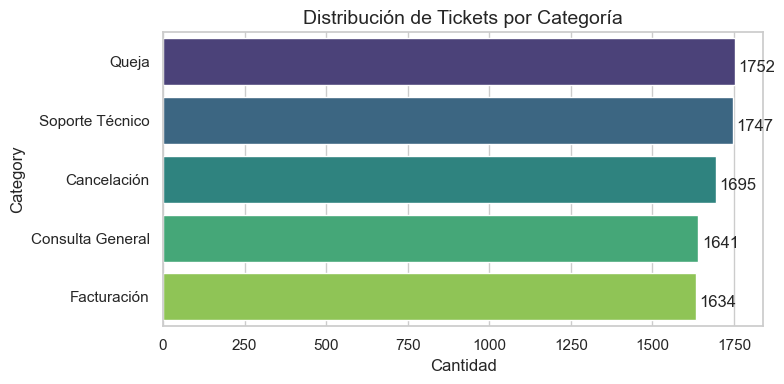

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Diccionario de mapeo de categorías
mapeo_categorias = {
    'Technical issue': 'Soporte Técnico',
    'Billing inquiry': 'Facturación',
    'Product inquiry': 'Consulta General',
    'Refund request': 'Queja',
    'Cancellation request': 'Cancelación'
}

# Aplicar el mapeo a la columna objetivo
df_model['Category'] = df_model['Ticket Type'].map(mapeo_categorias)

# Verificar que el mapeo fue exitoso
print("=== NUEVA DISTRIBUCIÓN DE CATEGORÍAS ===")
conteo = df_model['Category'].value_counts(dropna=False)
print(conteo)

# Crear un dataframe final solo con el texto procesado y la categoría
df_final = df_model[['Clean_Text', 'Category']].copy()

# ---GRÁFICA DE DISTRIBUCIÓN ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))
ax = sns.barplot(x=conteo.values, y=conteo.index, palette='viridis', hue=conteo.index, legend=False)
plt.title('Distribución de Tickets por Categoría', fontsize=14)
plt.xlabel('Cantidad', fontsize=12)

# Añadir las cantidades numéricas a la par de la barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width() + 10, p.get_y() + 0.5), va='center')
    
plt.tight_layout()
plt.show()

## 4. Implementación Manual de K-Folds Cross Validation

Como requerimiento técnico, se debe implementar K-Folds de forma manual (sin usar `sklearn.model_selection.KFold`). Se utilizará $K=5$.
El siguiente código mezcla el dataset aleatoriamente y genera una lista de 5 tuplas, donde cada tupla contiene `(DataFrame_Entrenamiento, DataFrame_Prueba)`.

In [5]:
import numpy as np

def generate_k_folds(df, k=5, seed=42):
    # 1. Mezclar el dataframe aleatoriamente (Shuffle)
    # Se usa una semilla (seed) para que los resultados sean reproducibles
    df_shuffled = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    
    # 2. Calcular el tamaño de cada pliegue (fold)
    n_samples = len(df_shuffled)
    fold_size = n_samples // k
    
    folds_data = []
    
    # 3. Iterar k veces para crear los conjuntos de train y test
    for i in range(k):
        # Índices de inicio y fin para el conjunto de prueba en esta iteración
        start_idx = i * fold_size
        # En el último fold, se toman todos los elementos restantes para no perder datos
        end_idx = (i + 1) * fold_size if i < k - 1 else n_samples
        
        # Extraer el conjunto de prueba
        test_fold = df_shuffled.iloc[start_idx:end_idx]
        
        # Extraer el conjunto de entrenamiento (todo lo que no es el test_fold)
        train_fold = pd.concat([df_shuffled.iloc[:start_idx], df_shuffled.iloc[end_idx:]])
        
        folds_data.append((train_fold, test_fold))
        
    return folds_data

# Generar los 5 pliegues
k_folds_splits = generate_k_folds(df_final, k=5)

# Verificar los tamaños de los conjuntos generados
print("=== VERIFICACIÓN DE TAMAÑOS DE K-FOLDS (K=5) ===")
for i, (train, test) in enumerate(k_folds_splits):
    print(f"Fold {i+1} -> Entrenamiento: {len(train)} filas | Prueba: {len(test)} filas")

=== VERIFICACIÓN DE TAMAÑOS DE K-FOLDS (K=5) ===
Fold 1 -> Entrenamiento: 6776 filas | Prueba: 1693 filas
Fold 2 -> Entrenamiento: 6776 filas | Prueba: 1693 filas
Fold 3 -> Entrenamiento: 6776 filas | Prueba: 1693 filas
Fold 4 -> Entrenamiento: 6776 filas | Prueba: 1693 filas
Fold 5 -> Entrenamiento: 6772 filas | Prueba: 1697 filas


## 5. Implementación Manual de Métricas de Evaluación

Para cumplir con la restricción de no utilizar bibliotecas automatizadas para la clasificación y evaluación, se definen las funciones matemáticas desde cero para calcular:
* **Matriz de Confusión**
* **Precisión, Recall y F1-Score (por clase)**
* **Accuracy Global y Macro F1**

In [6]:
def calcular_metricas_manuales(y_true, y_pred, clases):
    # 1. Construir Matriz de Confusión
    cm = {c_true: {c_pred: 0 for c_pred in clases} for c_true in clases}
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1
        
    metricas_clase = {}
    total_correctos = 0
    total_instancias = len(y_true)
    
    # 2. Calcular TP, FP, FN y métricas por clase
    for c in clases:
        TP = cm[c][c]
        total_correctos += TP
        
        FP = sum(cm[c_otra][c] for c_otra in clases if c_otra != c)
        FN = sum(cm[c][c_otra] for c_otra in clases if c_otra != c)
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        metricas_clase[c] = {
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        }
        
    # 3. Calcular métricas globales
    accuracy = total_correctos / total_instancias if total_instancias > 0 else 0.0
    macro_f1 = sum(m['F1-Score'] for m in metricas_clase.values()) / len(clases)
    
    return {
        'Matriz_Confusion': cm,
        'Metricas_Clase': metricas_clase,
        'Accuracy': accuracy,
        'Macro_F1': macro_f1
    }

print("Funciones de evaluación manual definidas correctamente.")

Funciones de evaluación manual definidas correctamente.


## 6. Entrenamiento y Evaluación K-Folds (Integración del Modelo)

En esta fase se integra la clase `NaiveBayesMultinomial`. El algoritmo requiere listas de tokens, por lo que el texto limpio se separa mediante `.split()` antes de ingresar al modelo.
Se itera sobre los 5 pliegues calculando el rendimiento y promediando los resultados finales.

In [7]:
from naive_bayes import NaiveBayesMultinomial

clases_unicas = list(mapeo_categorias.values())

# Acumuladores para el promedio de los K-Folds
k_accuracy = []
k_macro_f1 = []
k_metricas_clase = {c: {'Precision': [], 'Recall': [], 'F1-Score': []} for c in clases_unicas}

print("=== INICIANDO ENTRENAMIENTO K-FOLDS (K=5) ===")

for i, (train_df, test_df) in enumerate(k_folds_splits):
    print(f"\nProcesando Fold {i+1}...")
    
    # 1. Preparar datos: El modelo espera una lista de listas de palabras (tokens)
    X_train = train_df['Clean_Text'].apply(lambda x: x.split()).tolist()
    y_train = train_df['Category'].tolist()
    
    X_test = test_df['Clean_Text'].apply(lambda x: x.split()).tolist()
    y_test = test_df['Category'].tolist()
    
    # 2. Inicializar y Entrenar
    nb_model = NaiveBayesMultinomial()
    nb_model.train(X_train, y_train)
    
    # 3. Predecir conjunto de prueba
    y_pred = [nb_model.predict(doc) for doc in X_test]
    
    # 4. Calcular métricas de este Fold
    resultados = calcular_metricas_manuales(y_test, y_pred, clases_unicas)
    
    # Acumular resultados globales
    k_accuracy.append(resultados['Accuracy'])
    k_macro_f1.append(resultados['Macro_F1'])
    
    # Acumular resultados por clase
    for c in clases_unicas:
        k_metricas_clase[c]['Precision'].append(resultados['Metricas_Clase'][c]['Precision'])
        k_metricas_clase[c]['Recall'].append(resultados['Metricas_Clase'][c]['Recall'])
        k_metricas_clase[c]['F1-Score'].append(resultados['Metricas_Clase'][c]['F1-Score'])
        
    print(f"Fold {i+1} completado -> Accuracy: {resultados['Accuracy']:.4f} | Macro F1: {resultados['Macro_F1']:.4f}")

# Promedios Finales
print("\n=== RESULTADOS FINALES PROMEDIADOS (K-FOLDS) ===")
print(f"Accuracy Promedio: {sum(k_accuracy)/5:.4f}")
print(f"Macro F1 Promedio: {sum(k_macro_f1)/5:.4f}")

=== INICIANDO ENTRENAMIENTO K-FOLDS (K=5) ===

Procesando Fold 1...
Fold 1 completado -> Accuracy: 0.1949 | Macro F1: 0.1931

Procesando Fold 2...
Fold 2 completado -> Accuracy: 0.2056 | Macro F1: 0.2034

Procesando Fold 3...
Fold 3 completado -> Accuracy: 0.1914 | Macro F1: 0.1904

Procesando Fold 4...
Fold 4 completado -> Accuracy: 0.1931 | Macro F1: 0.1924

Procesando Fold 5...
Fold 5 completado -> Accuracy: 0.2062 | Macro F1: 0.2028

=== RESULTADOS FINALES PROMEDIADOS (K-FOLDS) ===
Accuracy Promedio: 0.1982
Macro F1 Promedio: 0.1964


## 7. Análisis de Métricas por Clase y Matriz de Confusión

A continuación, se extraen los promedios de Precisión, Recall y F1-Score para cada una de las 5 categorías evaluadas en el K-Folds. También se visualiza la Matriz de Confusión del último pliegue para analizar qué clases se están confundiendo entre sí.

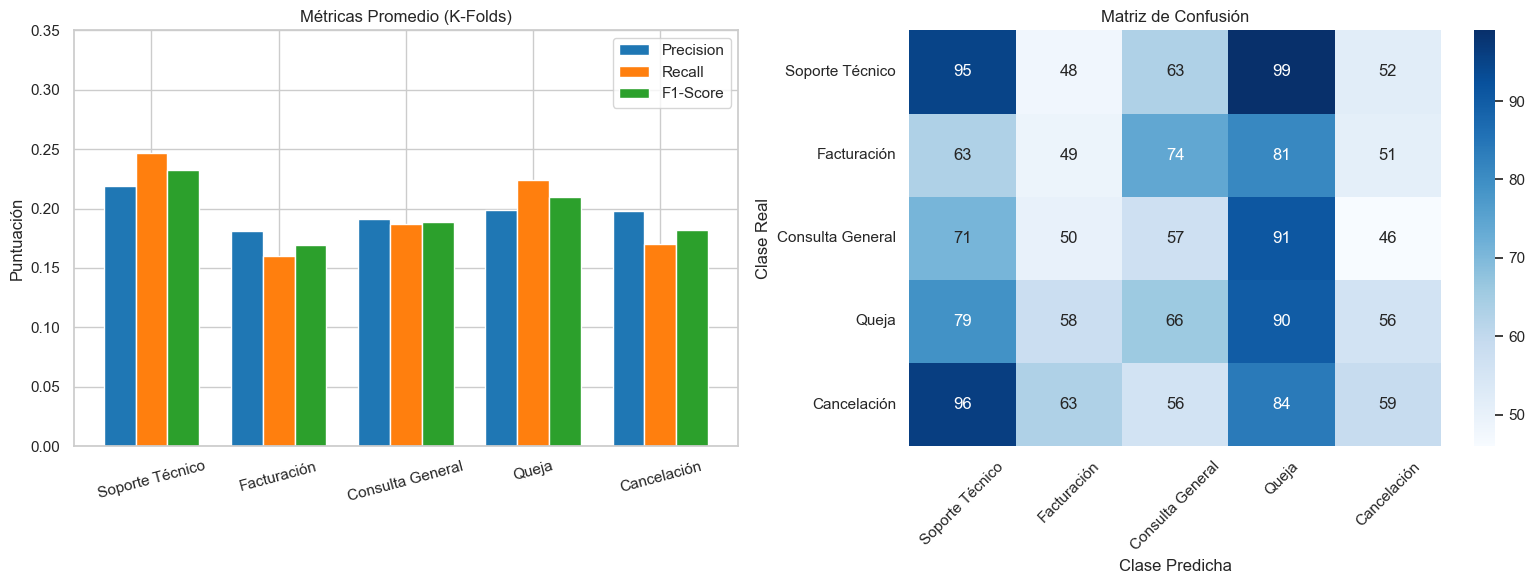

In [8]:
import numpy as np

precisiones = []
recalls = []
f1_scores = []

for c in clases_unicas:
    p_avg = sum(k_metricas_clase[c]['Precision']) / 5
    r_avg = sum(k_metricas_clase[c]['Recall']) / 5
    f1_avg = sum(k_metricas_clase[c]['F1-Score']) / 5
    
    precisiones.append(p_avg)
    recalls.append(r_avg)
    f1_scores.append(f1_avg)

cm = resultados['Matriz_Confusion']
encabezados = "".join([f"{c[:4]:>6}" for c in clases_unicas])
for c_true in clases_unicas:
    fila = "".join([f"{cm[c_true][c_pred]:>6}" for c_pred in clases_unicas])

# --- GRÁFICAS DE MÉTRICAS Y MATRIZ ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Barras de Métricas
x = np.arange(len(clases_unicas))
width = 0.25
ax1.bar(x - width, precisiones, width, label='Precision', color='#1f77b4')
ax1.bar(x, recalls, width, label='Recall', color='#ff7f0e')
ax1.bar(x + width, f1_scores, width, label='F1-Score', color='#2ca02c')

ax1.set_ylabel('Puntuación')
ax1.set_title('Métricas Promedio (K-Folds)')
ax1.set_xticks(x)
ax1.set_xticklabels(clases_unicas, rotation=15)
ax1.legend()
ax1.set_ylim(0, 0.35)

# Gráfica 2: Mapa de Calor (Heatmap) Matriz de Confusión
cm_matrix = [[cm[c_true][c_pred] for c_pred in clases_unicas] for c_true in clases_unicas]
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clases_unicas, yticklabels=clases_unicas, ax=ax2)
ax2.set_title('Matriz de Confusión')
ax2.set_ylabel('Clase Real')
ax2.set_xlabel('Clase Predicha')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Entrenamiento del Modelo Final y Persistencia

Una vez validadas las métricas y el comportamiento del modelo, se procede a entrenar el motor de inferencia utilizando el 100% del dataset disponible. Finalmente, el objeto del modelo se guarda en un archivo `modelo_final.pkl` para ser consumido por la aplicación web.

In [9]:
print("=== ENTRENANDO MODELO FINAL (100% DE LOS DATOS) ===")

# 1. Preparar todo el dataset
X_total = df_final['Clean_Text'].apply(lambda x: x.split()).tolist()
y_total = df_final['Category'].tolist()

# 2. Inicializar y Entrenar
modelo_final = NaiveBayesMultinomial()
modelo_final.train(X_total, y_total)

nombre_archivo = "modelo_final.pkl"
modelo_final.save(nombre_archivo)

print(f"¡Éxito! El modelo ha sido entrenado con {len(X_total)} tickets.")
print(f"Archivo '{nombre_archivo}' guardado correctamente en la carpeta actual.")

=== ENTRENANDO MODELO FINAL (100% DE LOS DATOS) ===
¡Éxito! El modelo ha sido entrenado con 8469 tickets.
Archivo 'modelo_final.pkl' guardado correctamente en la carpeta actual.
